In [1]:
import pandas as pd
df= pd.read_csv(r"C:\Users\D'Accubin Account\Documents\ALX EXPLORE DATA SCIENCE (PYTHON)\MD_agric_exam-4313.csv")
print (df.head())

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


   Field_ID  Elevation  Rainfall  Min_temperature_C  Max_temperature_C  \
0      1162  494.95615    1507.6               -5.4               31.0   
1      5108  663.73390     581.0               -4.7               30.9   
2      3504  396.87990    1715.1               -6.1               31.7   
3      5351  594.80370    1748.0               -4.3               33.6   
4       905  609.49800    1395.8               -4.5               31.3   

         pH  Pollution_level  Plot_size  Annual_yield Crop_type  
0  6.859436         0.007034        3.6      1.617421    coffee  
1  5.603219         0.289643        4.2      2.532497    potato  
2  5.774116         0.000409        2.6      1.262207    banana  
3  6.477415         0.088777        7.9      4.351564     wheat  
4  5.419586         0.050023       10.8      5.034791   cassava  


1. Write code to determine the number of unique crop types in the dataset?

In [2]:
#Method 1
df["Crop_type"].unique()
len(df["Crop_type"].unique())

#Method 2
df["Crop_type"].nunique()

8

2. Identify the maximum annual yield for "wheat" crop type in the dataset (rounded to 2 decimal places).

In [3]:
maximum_annual_yield_wheat=df[df["Crop_type"]=="wheat"]["Annual_yield"].max()
output=round(maximum_annual_yield_wheat,2)
print(output)

8.99


3. Find the total rainfall for crop types where the average pollution level is above 0.2.

In [14]:
#Method 1
average_pollution_level=df.groupby("Crop_type")["Pollution_level"].mean()
#print(average_pollution_level)
filtered_Crop_type=average_pollution_level[average_pollution_level>0.2]
#print(filtered_Crop_type)
filtered_df=df[df["Crop_type"].isin(filtered_Crop_type.index)]
total_rainfall=filtered_df["Rainfall"].sum()
print(total_rainfall)

#Method 2
group_df = df.groupby('Crop_type').agg({'Pollution_level':'mean', 'Rainfall':'sum'})
group_df[group_df['Pollution_level'] > 0.2]['Rainfall'].sum()
print(group_df)

941959.7
           Pollution_level  Rainfall
Crop_type                           
banana            0.093806  176599.3
cassava           0.327714  178709.1
coffee            0.220615  148849.5
maize             0.265101   57184.0
potato            0.252135   93860.2
rice              0.065531   79175.7
tea               0.214799  210650.5
wheat             0.223527  252706.4


4. Write a function to calculate the temperature range (Max_temperature_C - Min_temperature_C) for each farmer's field. Then, call the function with the following `Field_ID`: `1458`, `1895`, and `5443`. What are the results of these 3 calls?

In [7]:
def calculate_temperature_range(ID):
    Field_data=df[df["Field_ID"]==ID]
    temperature_range=Field_data["Max_temperature_C"].max()-Field_data["Min_temperature_C"].min()
    return temperature_range

In [8]:
calculate_temperature_range(1458)

40.7

In [9]:
calculate_temperature_range(1895)

35.7

In [10]:
calculate_temperature_range(5443)

33.4

Question 5

a = df['Crop_type'].unique()

b = float('inf')

c = ''

for crop in a:

    d = df[df['Crop_type'] == crop]['Min_temperature_C'].mean()

    if d < b:

        b = d

        c = crop

print(c)

avg_Min_temperature_C=df.groupby("Crop_type")["Min_temperature_C"].mean()
print(avg_Min_temperature_C)

6. Write code to calculate the total plot size for plots where the pH is less than 5.5.

In [21]:
Filtered_df=df[df["pH"]< 5.5]
#print(Filtered_df)
total_Plot_size=Filtered_df["Plot_size"].sum()
print(total_Plot_size)

1731.8999999999999


7. Using Pandas, create a dataframe that includes entries with a 'Min_temperature_C’< -5 and a 'Max_temperature_C' > 30. How many rows are in the filtered dataset?

In [27]:
Filtered_dataset=df[(df['Min_temperature_C']< -5) & (df['Max_temperature_C'] > 30)]
#print(Filtered_dataset)
output =len(Filtered_dataset)
print(output)

319


8. Using Numpy, calculate the standard deviation of the 'Rainfall' for plots where the 'Plot_size' is larger than the median plot size of the dataset (round to 2 decimal places).

In [30]:
import numpy as np
median_plot_size=np.median(df["Plot_size"])
#print(median_plot_size)
Filtered_plot=df[(df["Plot_size"]>median_plot_size)]
#print(Filtered_plot)
standard_deviation=np.std(Filtered_plot["Rainfall"])
output=round(standard_deviation, 2)
print(output)

469.62


9. If you concatenate the first three digits of the most common ‘Max_temperature_C’ with the last three letters of the least common 'Crop_type', what string do you get?
Note: Use the first mode if there are multiple modes

In [37]:
most_common_value=df['Max_temperature_C'].mode()[0] #0 is used to give us only the statement rather than index and statement
#print(most_common_value)
least_common_crop_type=df["Crop_type"].value_counts().idxmin()
#print(least_common_crop_type)
#Concatenate_string=str(most_common_value)[0:3]+(least_common_crop_type)[1:4]
#print(Concatenate_string)
Concatenate_string=str(most_common_value)[0:3]+(least_common_crop_type)[-3:] #negative indexing
print(Concatenate_string)

30.ice


10. Write Python code to create a violin plot visualising the distribution of 'Annual_yield' across different 'Elevation' ranges. Use the provided elevation range categories (Low: < 300m, Medium: 300m - 600m, High: > 600m) to categorise the data before plotting.  Examine the violin plot displaying the distribution of 'Annual Yield' across three elevation categories (Low, Medium, High). What insight does the violin plot provide regarding the relationship between elevation ranges and annual yield distribution?

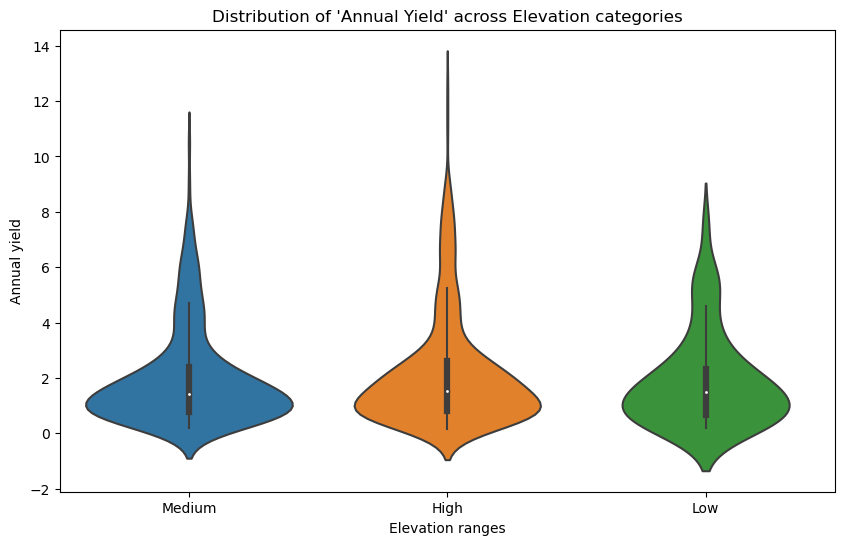

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
#Defining Elevation categories
def Elevation_ranges(elevation):
    if elevation < 300:
        return "Low"
    elif 300 <= elevation <= 600:
        return "Medium"
    else:
        return "High"
#Applying categorization and creating a new dataframe called elevation categories
df["Elevation_categories"]=df["Elevation"].apply(Elevation_ranges)
#Creating a violin plot
plt.figure(figsize=(10,6))
sns.violinplot(x='Elevation_categories',y='Annual_yield',data=df)
plt.title("Distribution of 'Annual Yield' across Elevation categories")
plt.xlabel("Elevation ranges")
plt.ylabel("Annual yield")
plt.show()

11. Assuming each 'Crop_type' contributes an integer value equal to its length (e.g., 'wheat' contributes 5), write a recursive function to sum the integer values for each unique crop type in the dataset. What is the sum?

In [65]:
#Method 1
def total_crop_length(input):
    if input.empty:
        return 0
    unique_crop_type=set(input)
    def sum(unique_crop_type):
        if not unique_crop_type:
            return 0
        crop_type=unique_crop_type.pop()
        output=len(crop_type)+sum(unique_crop_type)
        return output
    return sum(unique_crop_type)

In [66]:
input=df["Crop_type"]
result=total_crop_length(input)
print(result)

42


In [69]:
#Method 2
def unique_crop_length_sum(crops, seen=None):
    if seen is None:
        seen = set()

    # Base case: if crops is empty, return 0
    if not crops:
        return 0

    # Current crop
    current_crop = crops[0]

    # If the crop hasn't been seen, add its length to the sum and include it in seen
    if current_crop not in seen:
        seen.add(current_crop)
        # Sum the length of the current unique crop with the sum of the rest
        return len(current_crop) + unique_crop_length_sum(crops[1:], seen)
    else:
        # Continue to the next crop without adding to the sum
        return unique_crop_length_sum(crops[1:], seen)

In [72]:
crops=df["Crop_type"].unique().tolist()
sum_length = unique_crop_length_sum(crops)

sum_length

42

12. Write Python code to perform a t-test comparing the average 'Annual_yield' between 'coffee' and 'banana' crop types using scipy.stats. What is the p-value, rounded to three decimal places?

In [83]:
#Method 1
from scipy import stats
coffee_yield=df[df["Crop_type"]=="coffee"]["Annual_yield"]
banana_yield=df[df["Crop_type"]=="banana"]["Annual_yield"]
t_test,p_value=stats.ttest_ind(coffee_yield,banana_yield)
p_value=round(p_value,3)
print(p_value)

#Method 2
from scipy import stats
from scipy.stats import ttest_ind
import pandas as pd
coffee_yield=df[df["Crop_type"]=="coffee"]["Annual_yield"]
banana_yield=df[df["Crop_type"]=="banana"]["Annual_yield"]
t_test,p_value=stats.ttest_ind(coffee_yield,banana_yield)
p_value=round(p_value,3)
print(p_value)

0.598
